In [2]:
# import
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sentiment import analyze_sentiment

In [4]:
from themes import extract_keywords, assign_theme

In [4]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dania\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [5]:
from text_preprocessing import clean_text

In [6]:
#Load dataset
df = pd.read_csv('../data/clean_reviews.csv')

df.head()

,review_id,review,rating,date,bank,source
0,5c08f975-fcca-4b2d-8044-25490b83e988,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play
1,c1e25b5d-7e79-4b60-8aa5-bed69a904f62,worst,1,2026-05-16,CBE,Google Play
2,eb3cc438-1c10-4e72-8851-3efff6a04135,this app very full,5,2026-05-16,CBE,Google Play
3,f8209985-ea16-4f28-bb48-d6a7276f0f08,good apps,4,2026-05-16,CBE,Google Play
4,a983bc98-7ea7-4ac6-8fed-039ed2a7de0a,ok,5,2026-05-16,CBE,Google Play


In [7]:
# Review the dataset
df['clean_review'] = df['review'].apply(clean_text)

df.head()

,review_id,review,rating,date,bank,source,clean_review
0,5c08f975-fcca-4b2d-8044-25490b83e988,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,
1,c1e25b5d-7e79-4b60-8aa5-bed69a904f62,worst,1,2026-05-16,CBE,Google Play,worst
2,eb3cc438-1c10-4e72-8851-3efff6a04135,this app very full,5,2026-05-16,CBE,Google Play,app very full
3,f8209985-ea16-4f28-bb48-d6a7276f0f08,good apps,4,2026-05-16,CBE,Google Play,good apps
4,a983bc98-7ea7-4ac6-8fed-039ed2a7de0a,ok,5,2026-05-16,CBE,Google Play,ok


In [8]:
# Run sentiment analyis
df = analyze_sentiment(df)

df.head()

,review_id,review,rating,date,bank,source,clean_review,sentiment_label,sentiment_score
0,5c08f975-fcca-4b2d-8044-25490b83e988,🤙🏼🤙🏼,5,2026-05-16,CBE,Google Play,,POSITIVE,0.7506
1,c1e25b5d-7e79-4b60-8aa5-bed69a904f62,worst,1,2026-05-16,CBE,Google Play,worst,NEGATIVE,-0.6249
2,eb3cc438-1c10-4e72-8851-3efff6a04135,this app very full,5,2026-05-16,CBE,Google Play,app very full,NEUTRAL,0.0000
3,f8209985-ea16-4f28-bb48-d6a7276f0f08,good apps,4,2026-05-16,CBE,Google Play,good apps,POSITIVE,0.4404
4,a983bc98-7ea7-4ac6-8fed-039ed2a7de0a,ok,5,2026-05-16,CBE,Google Play,ok,POSITIVE,0.2960


In [9]:
# Sentiment distribution
df['sentiment_label'].value_counts()

sentiment_label
POSITIVE    605
NEUTRAL     254
NEGATIVE    141
Name: count, dtype: int64

In [10]:
# Aggregate by bank
sentiment_summary = df.groupby(
    ['bank', 'sentiment_label']
).size().unstack(fill_value=0)

sentiment_summary

sentiment_label,NEGATIVE,NEUTRAL,POSITIVE
bank,,,
BOA,90,144,266
CBE,51,110,339


In [11]:
#Aggregate by rating
rating_sentiment = df.groupby('rating')['sentiment_score'].mean()

rating_sentiment

rating
1   -0.121274
2    0.122189
3    0.024106
4    0.263841
5    0.383135
Name: sentiment_score, dtype: float64

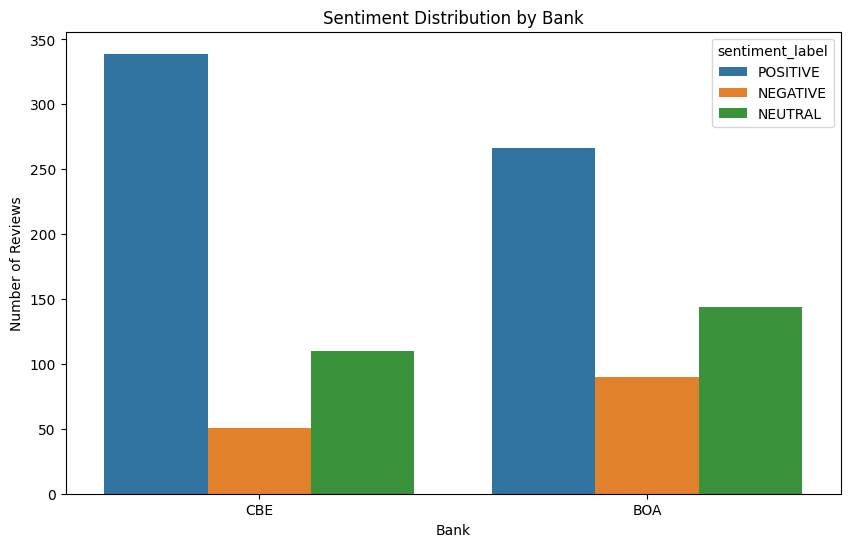

In [12]:
#Visualization
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='bank',
    hue='sentiment_label'
)

plt.title('Sentiment Distribution by Bank')
plt.xlabel('Bank')
plt.ylabel('Number of Reviews')

plt.show()

In [13]:
#Extract keyword
banks = df['bank'].unique()

for bank in banks:

    print(f'\\nTop Keywords for {bank}:\\n')

    bank_reviews = df[df['bank'] == bank]['clean_review']

    keywords = extract_keywords(bank_reviews)

    print(keywords)

\nTop Keywords for CBE:\n
['app' 'application' 'bank' 'best' 'cbe' 'easy' 'excellent' 'fast' 'good'
 'like' 'mobile' 'nice' 'nice app' 'ok' 'service' 'transfer' 'update'
 'use' 'work' 'working']
\nTop Keywords for BOA:\n
['app' 'bank' 'banking' 'best' 'boa' 'doesnt' 'fast' 'fix' 'good' 'like'
 'mobile' 'mobile banking' 'money' 'nice' 'time' 'update' 'use' 'work'
 'working' 'worst']


# Theme Grouping Logic

The extracted keywords were manually grouped into business-relevant themes.

Examples:

- login, password → Account Access Issues
- slow transfer, loading → Transaction Performance
- OTP, verification → Authentication Problems
- fingerprint login → Feature Requests
- UI, navigation → User Experience

In [14]:
#Assign theme
df['identified_theme'] = df['review'].apply(assign_theme)

df[['review', 'identified_theme']].head()

,review,identified_theme
0,🤙🏼🤙🏼,Other
1,worst,Other
2,this app very full,Other
3,good apps,Other
4,ok,Other


In [15]:
# Theme distribution
df['identified_theme'].value_counts()

identified_theme
Other                      856
Transaction Performance     64
Feature Requests            32
UI & User Experience        28
Account Access Issues       11
Authentication Problems      9
Name: count, dtype: int64

In [16]:
#Save final csv
df = df.rename(columns={'review': 'review_text'})
df.to_csv('../data/final_reviews.csv', index=False)

print('Final dataset saved successfully.')

Final dataset saved successfully.
